# Baseline Training

This notebook is a practical wrapper around `src/train_baseline.py` so we can test the full training pipeline end to end.

It helps us:
- choose between `resnet18` and `mobilenet_v3_large`;
- test privacy modes such as `none`, `blur`, `edges`, and `noise`;
- run a quick smoke test, a safer GPU run, or the original full-size training;
- inspect saved metrics, classification report, checkpoint, and plots.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from PIL import Image
from IPython.display import display

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().resolve().parent
else:
    PROJECT_ROOT = Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.configs import (
    DEFAULT_DATA_ROOT,
    RESULTS_MODELS_DIR,
    RESULTS_PLOTS_DIR,
    SRC_DIR,
    BaselineExperimentConfig,
    build_train_command,
    resolve_python_bin,
)

PYTHON_BIN = resolve_python_bin()
TRAIN_SCRIPT = SRC_DIR / "train_baseline.py"
DATA_ROOT = DEFAULT_DATA_ROOT

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

print("Project root:", PROJECT_ROOT)
print("Python used for training:", PYTHON_BIN)
print("Default data root:", DATA_ROOT)

Project root: C:\Users\Tiago\Documents\GitHub\privacy-fer
Python used for training: C:\Users\Tiago\Documents\GitHub\privacy-fer\.venv\Scripts\python.exe
Default data root: C:\Users\Tiago\Documents\GitHub\privacy-fer\data\raw\balanced-raf-db-dataset-7575-grayscale


In [2]:
# Profiles: "smoke", "safe", "original", "gpu_tuned"
RUN_PROFILE = "gpu_tuned"
MODEL_NAME = "resnet18"

if RUN_PROFILE == "smoke":
    config = BaselineExperimentConfig.smoke_test_config(
        model=MODEL_NAME,
        weights="pretrained",
        privacy_mode="none",
        privacy_intensity=0,
    )
elif RUN_PROFILE == "safe":
    config = BaselineExperimentConfig.safe_gpu_config(
        model=MODEL_NAME,
        privacy_mode="none",
        privacy_intensity=0,
    )
elif RUN_PROFILE == "gpu_tuned":
    config = BaselineExperimentConfig.gpu_tuned_config(
        model=MODEL_NAME,
        privacy_mode="none",
        privacy_intensity=0,
    )
elif RUN_PROFILE in {"original", "full"}:
    config = BaselineExperimentConfig.original_config(
        model=MODEL_NAME,
        weights="pretrained",
        privacy_mode="none",
        privacy_intensity=0,
    )
else:
    raise ValueError(f"Unsupported RUN_PROFILE: {RUN_PROFILE}")

RUN_NAME = config.run_name
PLOT_PATH = config.plot_path
METRICS_PATH = config.metrics_path
REPORT_PATH = config.report_path
CHECKPOINT_PATH = config.checkpoint_path

pd.DataFrame([config.as_dict()]).T.rename(columns={0: "value"})

,value
model,resnet18
weights,pretrained
privacy_mode,none
privacy_intensity,0
epochs,10
batch_size,64
learning_rate,0.0001
weight_decay,0.0001
image_size,224
num_workers,2


In [3]:
required_paths = {
    "train_script": TRAIN_SCRIPT,
    "data_root": DATA_ROOT,
    "venv_python": PYTHON_BIN,
}

for name, path in required_paths.items():
    print(f"{name}: {path} | exists={path.exists()}")

train_folders = sorted(path.name for path in (DATA_ROOT / "train").iterdir() if path.is_dir())
print("Train classes:", train_folders)

train_script: C:\Users\Tiago\Documents\GitHub\privacy-fer\src\train_baseline.py | exists=True
data_root: C:\Users\Tiago\Documents\GitHub\privacy-fer\data\raw\balanced-raf-db-dataset-7575-grayscale | exists=True
venv_python: C:\Users\Tiago\Documents\GitHub\privacy-fer\.venv\Scripts\python.exe | exists=True
Train classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [4]:
command = build_train_command(
    config=config,
    train_script=TRAIN_SCRIPT,
    python_bin=PYTHON_BIN,
    data_root=DATA_ROOT,
)

print(subprocess.list2cmdline(command))

C:\Users\Tiago\Documents\GitHub\privacy-fer\.venv\Scripts\python.exe C:\Users\Tiago\Documents\GitHub\privacy-fer\src\train_baseline.py --model resnet18 --weights pretrained --data-root C:\Users\Tiago\Documents\GitHub\privacy-fer\data\raw\balanced-raf-db-dataset-7575-grayscale --epochs 10 --batch-size 64 --learning-rate 0.0001 --weight-decay 0.0001 --num-workers 2 --image-size 224 --privacy-mode none --privacy-intensity 0 --seed 42 --plot-path C:\Users\Tiago\Documents\GitHub\privacy-fer\results\plots\resnet18_none_0p0_gpu_tuned_metrics.png --pin-memory --persistent-workers --prefetch-factor 2 --run-suffix gpu_tuned


In [5]:
result = subprocess.run(
    command,
    cwd=PROJECT_ROOT,
    text=True,
    capture_output=True,
)

print("Return code:", result.returncode)
print()
print("STDOUT")
print(result.stdout)

if result.stderr.strip():
    print("STDERR")
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError("Training script failed. Check the output above.")

Return code: 1

STDOUT
DataLoader config: batch_size=64 | num_workers=2 | pin_memory=True | persistent_workers=True | prefetch_factor=2

STDERR
Traceback (most recent call last):
  File "C:\Users\Tiago\Documents\GitHub\privacy-fer\src\train_baseline.py", line 716, in <module>
    main()
  File "C:\Users\Tiago\Documents\GitHub\privacy-fer\src\train_baseline.py", line 712, in main
    train(args)
  File "C:\Users\Tiago\Documents\GitHub\privacy-fer\src\train_baseline.py", line 620, in train
    train_metrics = run_epoch(
  File "C:\Users\Tiago\Documents\GitHub\privacy-fer\src\train_baseline.py", line 367, in run_epoch
    for images, targets in dataloader:
  File "C:\Users\Tiago\Documents\GitHub\privacy-fer\.venv\lib\site-packages\torch\utils\data\dataloader.py", line 479, in __iter__
    self._iterator = self._get_iterator()
  File "C:\Users\Tiago\Documents\GitHub\privacy-fer\.venv\lib\site-packages\torch\utils\data\dataloader.py", line 415, in _get_iterator
    return _MultiProcessingDa

RuntimeError: Training script failed. Check the output above.

In [ ]:
if not METRICS_PATH.exists():
    raise FileNotFoundError(f"Metrics file not found: {METRICS_PATH}")

with METRICS_PATH.open("r", encoding="utf-8") as handle:
    metrics_payload = json.load(handle)

test_metrics_df = pd.DataFrame(
    list(metrics_payload["test_metrics"].items()),
    columns=["metric", "value"],
)
test_metrics_df

,metric,value
0,accuracy,0.960144
1,precision_macro,0.960735
2,recall_macro,0.960144
3,f1_macro,0.960293
4,precision_weighted,0.960735
5,recall_weighted,0.960144
6,f1_weighted,0.960293
7,loss,0.158205


In [ ]:
train_history = pd.DataFrame(metrics_payload["history"]["train"])
val_history = pd.DataFrame(metrics_payload["history"]["val"])

train_history.insert(0, "epoch", range(1, len(train_history) + 1))
val_history.insert(0, "epoch", range(1, len(val_history) + 1))

print("Train history")
display(train_history)
print("Validation history")
display(val_history)

Train history


,epoch,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,loss
0,1,0.747827,0.748113,0.747827,0.747794,0.748113,0.747827,0.747794,0.700382
1,2,0.908070,0.908298,0.908070,0.908155,0.908298,0.908070,0.908155,0.269792
2,3,0.948739,0.948806,0.948739,0.948757,0.948806,0.948739,0.948757,0.152162
3,4,0.963794,0.963857,0.963794,0.963816,0.963857,0.963794,0.963816,0.109506
4,5,0.969190,0.969228,0.969190,0.969205,0.969228,0.969190,0.969205,0.092161
5,6,0.976252,0.976268,0.976252,0.976257,0.976268,0.976252,0.976257,0.069422
6,7,0.977984,0.978006,0.977984,0.977992,0.978006,0.977984,0.977992,0.063995
7,8,0.981681,0.981685,0.981681,0.981682,0.981685,0.981681,0.981682,0.050714
8,9,0.983046,0.983066,0.983046,0.983054,0.983066,0.983046,0.983054,0.049822
9,10,0.984945,0.984947,0.984945,0.984945,0.984947,0.984945,0.984945,0.042442


Validation history


,epoch,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,loss
0,1,0.871402,0.873809,0.871402,0.871742,0.873809,0.871402,0.871742,0.368989
1,2,0.928305,0.929781,0.928305,0.928683,0.929781,0.928305,0.928683,0.215786
2,3,0.933769,0.934402,0.933769,0.933784,0.934402,0.933769,0.933784,0.201110
3,4,0.930704,0.934934,0.930704,0.931282,0.934934,0.930704,0.931282,0.202115
4,5,0.936301,0.937200,0.936301,0.936110,0.937200,0.936301,0.936110,0.190282
5,6,0.947361,0.948081,0.947361,0.947173,0.948081,0.947361,0.947173,0.178782
6,7,0.946562,0.947221,0.946562,0.946274,0.947221,0.946562,0.946274,0.180237
7,8,0.949227,0.949676,0.949227,0.949272,0.949676,0.949227,0.949272,0.181438
8,9,0.960421,0.960842,0.960421,0.960521,0.960842,0.960421,0.960521,0.136219
9,10,0.948028,0.949331,0.948028,0.948210,0.949331,0.948028,0.948210,0.180400


In [ ]:
if REPORT_PATH.exists():
    print(REPORT_PATH.read_text(encoding="utf-8"))
else:
    print("Classification report not found.")

              precision    recall  f1-score   support

    surprise     0.9699    0.9765    0.9732       595
        fear     0.9949    0.9882    0.9916       595
     disgust     0.9745    0.9647    0.9696       595
       happy     0.9700    0.9244    0.9466       595
         sad     0.9327    0.9546    0.9435       595
       angry     0.9933    0.9899    0.9916       595
     neutral     0.8898    0.9227    0.9059       595

    accuracy                         0.9601      4165
   macro avg     0.9607    0.9601    0.9603      4165
weighted avg     0.9607    0.9601    0.9603      4165



In [ ]:
artifacts_df = pd.DataFrame(
    [
        {"artifact": "checkpoint", "path": str(CHECKPOINT_PATH), "exists": CHECKPOINT_PATH.exists()},
        {"artifact": "metrics_json", "path": str(METRICS_PATH), "exists": METRICS_PATH.exists()},
        {"artifact": "classification_report", "path": str(REPORT_PATH), "exists": REPORT_PATH.exists()},
        {"artifact": "plot", "path": str(PLOT_PATH), "exists": PLOT_PATH.exists()},
    ]
)
artifacts_df

,artifact,path,exists
0,checkpoint,C:\Users\Tiago\Documents\GitHub\privacy-fer\re...,True
1,metrics_json,C:\Users\Tiago\Documents\GitHub\privacy-fer\re...,True
2,classification_report,C:\Users\Tiago\Documents\GitHub\privacy-fer\re...,True
3,plot,C:\Users\Tiago\Documents\GitHub\privacy-fer\re...,True


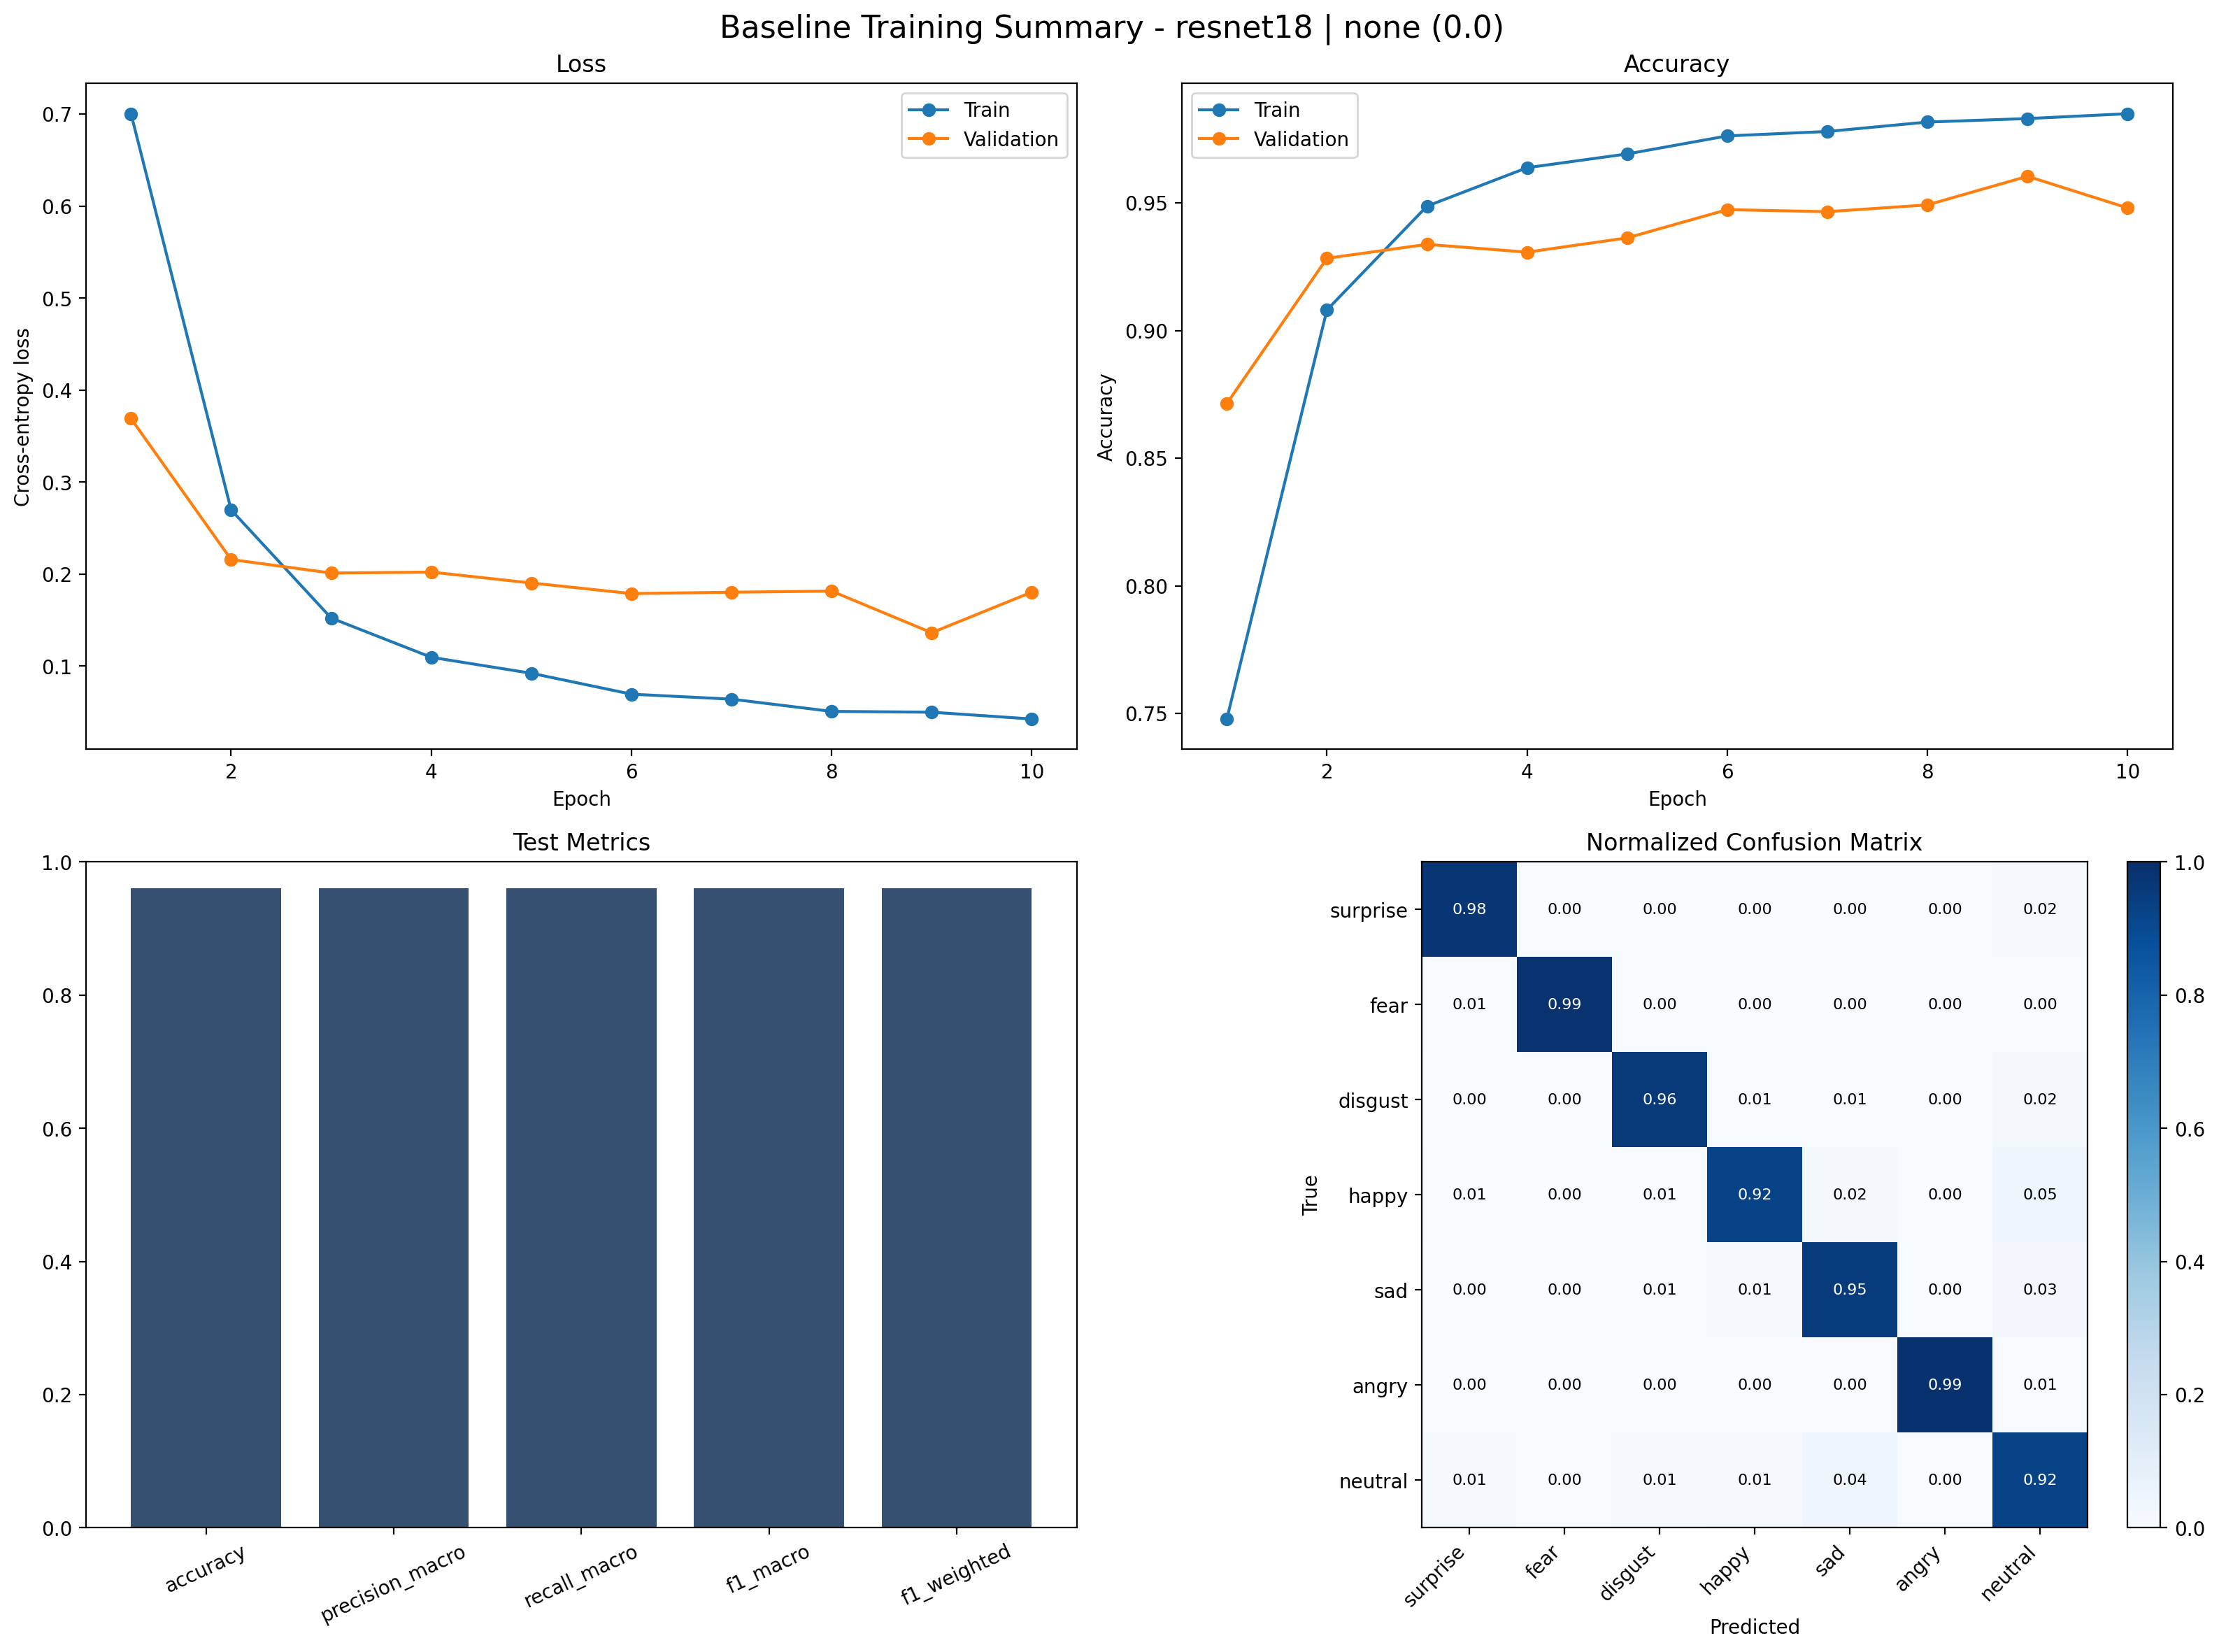

In [ ]:
if PLOT_PATH.exists():
    display(Image.open(PLOT_PATH))
else:
    print("Plot not found.")

In [ ]:
all_metrics_files = sorted(RESULTS_MODELS_DIR.glob("*_metrics.json"))
rows = []

for metrics_file in all_metrics_files:
    payload = json.loads(metrics_file.read_text(encoding="utf-8"))
    row = {
        "run": metrics_file.stem.replace("_metrics", ""),
        "model": payload.get("model"),
        "weights": payload.get("weights"),
        "run_suffix": payload.get("run_suffix"),
        "privacy_mode": payload.get("privacy_mode"),
        "privacy_intensity": payload.get("privacy_intensity"),
        "batch_size": payload.get("batch_size"),
        "image_size": payload.get("image_size"),
        "num_workers": payload.get("num_workers"),
        "pin_memory": payload.get("pin_memory"),
        "persistent_workers": payload.get("persistent_workers"),
        "prefetch_factor": payload.get("prefetch_factor"),
        "best_epoch": payload.get("best_epoch"),
    }
    row.update(payload.get("test_metrics", {}))
    rows.append(row)

comparison_df = pd.DataFrame(rows)
if not comparison_df.empty:
    comparison_df = comparison_df.sort_values(by=["f1_macro", "accuracy"], ascending=False)

comparison_df

,run,model,weights,privacy_mode,privacy_intensity,best_epoch,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,loss
1,resnet18_none_0p0,resnet18,pretrained,none,0.0,9,0.960144,0.960735,0.960144,0.960293,0.960735,0.960144,0.960293,0.158205
0,mobilenet_v3_large_none_0p0,mobilenet_v3_large,pretrained,none,0.0,5,0.934694,0.934576,0.934694,0.934210,0.934576,0.934694,0.934210,0.255273


## Suggested Next Experiments

- switch from `resnet18` to `mobilenet_v3_large`;
- compare `none` versus `blur`, `edges`, and `noise`;
- turn `SMOKE_TEST = False` for a real baseline run;
- keep the notebook as a lightweight experiment runner while the training logic stays in `src/train_baseline.py`.